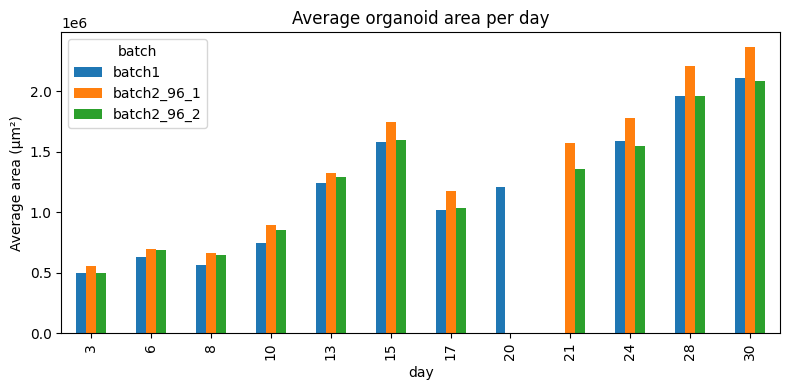

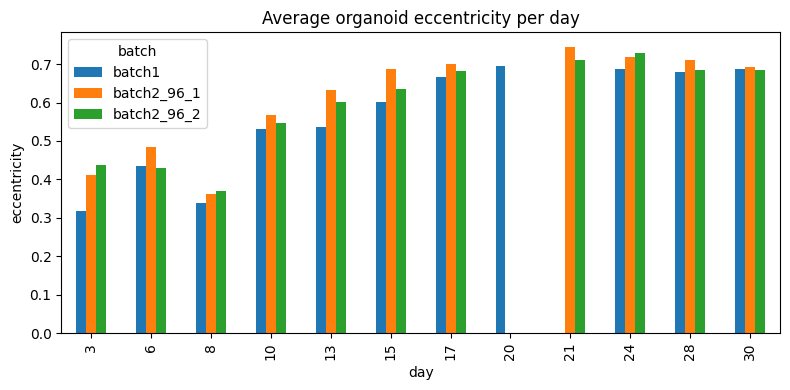

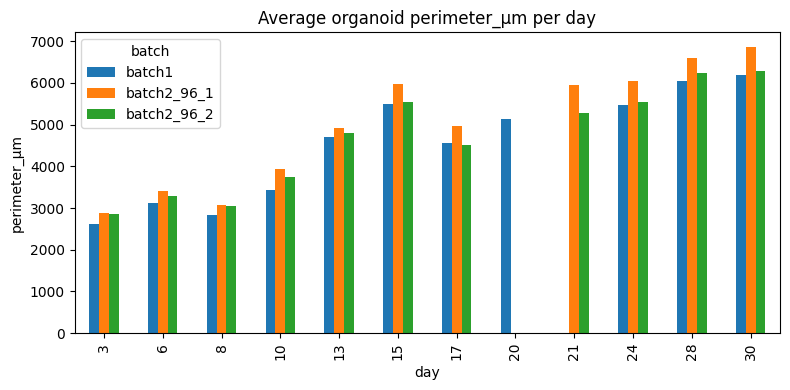

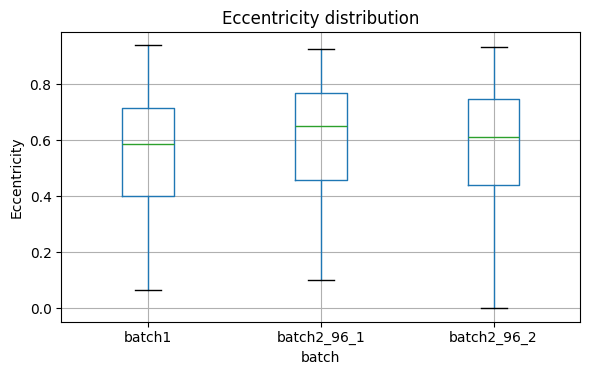

In [9]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

csv_path = Path("/net/projects2/promega/data-analysis/output/processed_dataset_256x192/mask_metrics.csv")
df = pd.read_csv(csv_path)

# ── keep batches 1 & 2 ──
df = df[df["batch_day"].isin(["batch1", "batch2_96_1", "batch2_96_2"])].copy()

# ── day and batch columns ──
df["day"]   = (
    df["img_id"]
      .str.extract(r"Dy(\d+)", expand=False)   # pulls 03, 06, 28 …
      .astype(int)
)
df["batch"] = df["batch_day"]                 # already “batch1/2”

# ── 1) average area per day ──
avg_area = df.groupby(["batch", "day"])["area_μm2"].mean().unstack(level=0)
avg_area.plot(kind="bar", figsize=(8,4))
plt.ylabel("Average area (µm²)")
plt.title("Average organoid area per day")
plt.tight_layout()
plt.show()

# ── 1) average area per day ──
avg_area = df.groupby(["batch", "day"])["eccentricity"].mean().unstack(level=0)
avg_area.plot(kind="bar", figsize=(8,4))
plt.ylabel("eccentricity")
plt.title("Average organoid eccentricity per day")
plt.tight_layout()
plt.show()

# ── 1) average area per day ──
avg_area = df.groupby(["batch", "day"])["perimeter_μm"].mean().unstack(level=0)
avg_area.plot(kind="bar", figsize=(8,4))
plt.ylabel("perimeter_µm")
plt.title("Average organoid perimeter_µm per day")
plt.tight_layout()
plt.show()

# ── 2) eccentricity distribution ──
df.boxplot(column="eccentricity", by="batch", figsize=(6,4))
plt.suptitle("")
plt.title("Eccentricity distribution")
plt.ylabel("Eccentricity")
plt.tight_layout()
plt.show()


In [12]:
# ----------------------------------------
# quick_morphology_metrics.py
# ----------------------------------------
import json, math
from pathlib import Path

import cv2
import numpy as np
import pandas as pd
from skimage import measure, morphology

# ---------- core metric function ----------
def shape_metrics(mask_bin: np.ndarray, px_um: float):
    """Return shape metrics (largest region) in physical units."""
    # regionprops wants integer labels
    regions = measure.regionprops(mask_bin.astype(int))
    if not regions:
        return None  # empty mask

    props = max(regions, key=lambda r: r.area)  # largest region
    area_px  = props.area
    peri_px  = props.perimeter
    major_px = props.major_axis_length
    minor_px = props.minor_axis_length

    hull     = morphology.convex_hull_image(mask_bin)
    peri_ch_px  = measure.perimeter(hull)
    area_ch_px  = hull.sum()

    circularity = 4 * math.pi * area_px / (peri_px ** 2)
    solidity    = area_px / area_ch_px
    convexity   = peri_ch_px / peri_px
    aspect      = major_px / minor_px
    roughness   = peri_px / peri_ch_px

    # convert to microns
    um = px_um
    return dict(
        area_um2     = area_px  * um ** 2,
        perimeter_um = peri_px  * um,
        major_um     = major_px * um,
        minor_um     = minor_px * um,
        circularity  = circularity,
        solidity     = solidity,
        convexity    = convexity,
        roughness    = roughness,
        aspect_ratio = aspect,
    )

# ---------- iterate over every mapping ----------
root = Path("/net/projects2/promega/data-analysis/output/processed_dataset_256x192")
out_rows = []

for jp in root.rglob("image_mapping_*_processed.json"):
    mapping = json.loads(jp.read_text())
    print("•", jp.relative_to(root))
    for img_id, info in mapping.items():
        mask_path = Path(info["mask_path"])
        if not mask_path.exists():
            print("  ⚠️  missing mask:", mask_path.name)
            continue

        mask_bin = cv2.imread(str(mask_path), cv2.IMREAD_GRAYSCALE) > 127
        if mask_bin.sum() == 0:
            print("  ⚠️  empty mask:", mask_path.name)
            continue

        m = shape_metrics(mask_bin, info["final_um_per_px"])
        if m:
            m.update(
                img_id     = img_id,
                batch_day  = mask_path.parts[-4],       # e.g. batch2_96_1/day03
            )
            out_rows.append(m)

# ---------- save ----------
df = pd.DataFrame(out_rows)
out_csv = root / "morphology_metrics.csv"
df.to_csv(out_csv, index=False)
print(f"\nSaved {len(df)} objects →  {out_csv}")


• BA2_96_2_Dy06/image_mapping_BA2_96_2_Dy06_processed.json
  ⚠️  empty mask: Ba2_96_2_Dy06_H12_predmask.png
• BA3_Dy08/image_mapping_BA3_Dy08_processed.json
  ⚠️  empty mask: Ba3_Pt1_Dy08_D9_predmask.png
• BA3_Dy30/image_mapping_BA3_Dy30_processed.json
• BA2_96_2_Dy15/image_mapping_BA2_96_2_Dy15_processed.json
• BA1_Dy13/image_mapping_BA1_Dy13_processed.json
• BA3_Dy24/image_mapping_BA3_Dy24_processed.json
• BA2_96_1_Dy21/image_mapping_BA2_96_1_Dy21_processed.json
  ⚠️  empty mask: Ba2_96_1_Dy21_A1_predmask.png
  ⚠️  empty mask: Ba2_96_1_Dy21_B12_predmask.png
• BA2_96_1_Dy13/image_mapping_BA2_96_1_Dy13_processed.json
• BA2_96_1_Dy17/image_mapping_BA2_96_1_Dy17_processed.json
• BA1_Dy17/image_mapping_BA1_Dy17_processed.json
• BA2_96_2_Dy24/image_mapping_BA2_96_2_Dy24_processed.json
  ⚠️  empty mask: Ba2_96_2_Dy24_A10_predmask.png
  ⚠️  empty mask: Ba2_96_2_Dy24_A12_predmask.png
  ⚠️  empty mask: Ba2_96_2_Dy24_A8_predmask.png
• BA1_Dy10/image_mapping_BA1_Dy10_processed.json
• BA2_96_1_Dy

In [13]:

csv_path = Path("/net/projects2/promega/data-analysis/output/processed_dataset_256x192/morphology_metrics.csv")
df = pd.read_csv(csv_path)

In [15]:
print(df.columns)
print(df.head())

Index(['area_um2', 'perimeter_um', 'major_um', 'minor_um', 'circularity',
       'solidity', 'convexity', 'roughness', 'aspect_ratio', 'img_id',
       'batch_day'],
      dtype='object')
        area_um2  perimeter_um     major_um    minor_um  circularity  \
0     939.936403     86.715000    48.475159   21.678750     1.570796   
1  605789.011814   2934.147643   910.228761  850.953142     0.884234   
2  648203.642005   3046.712128   933.181925  889.715051     0.877523   
3  714469.158425   3343.865069  1060.038120  872.388143     0.802964   
4  715644.078929   3186.853672   974.420035  939.460383     0.885488   

   solidity  convexity  roughness  aspect_ratio             img_id  \
0  1.000000   1.000000   1.000000      2.236068   Ba2 96_2 Dy06 A1   
1  0.977255   1.000000   1.000000      1.069658  Ba2 96_2 Dy06 A10   
2  0.976979   1.000000   1.000000      1.048855  Ba2 96_2 Dy06 A11   
3  0.957035   0.973146   1.027595      1.215099  Ba2 96_2 Dy06 A12   
4  0.982578   1.000000   1.00

In [3]:
print(df.columns)  

Index(['area_μm2', 'perimeter_μm', 'major_ax_μm', 'minor_ax_μm',
       'eccentricity', 'img_id', 'batch_day', 'day', 'batch'],
      dtype='object')


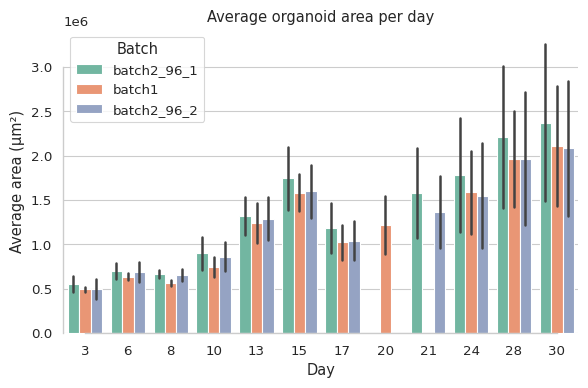

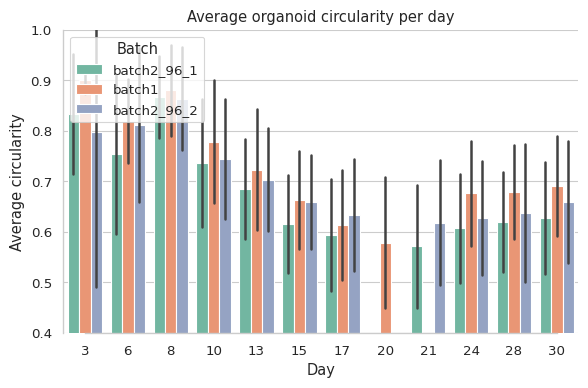

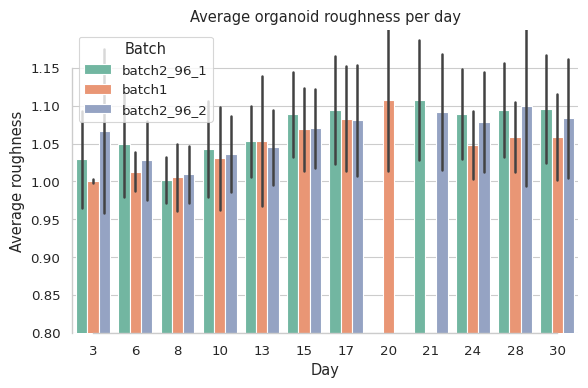

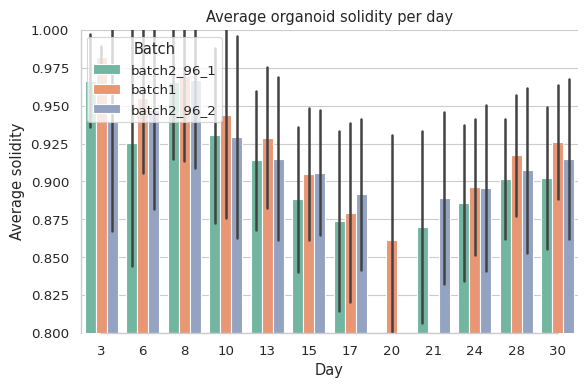

In [7]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# Load data
csv_path = Path("/net/projects2/promega/data-analysis/output/processed_dataset_256x192/morphology_metrics.csv")
df = pd.read_csv(csv_path)

# Filter and preprocess
df = df[df["batch_day"].isin(["batch1", "batch2_96_1", "batch2_96_2"])].copy()
df["day"] = df["img_id"].str.extract(r"Dy(\d+)", expand=False).astype(int)
df["batch"] = df["batch_day"]

# Seaborn theme
sns.set_theme(
    context="paper",
    style="whitegrid",
    palette="Set2",
    font="DejaVu Sans",
    font_scale=1.1
)

# Function for bar plots
def plot_bar(metric, ylabel, title, ylim=None):
    plt.figure(figsize=(6, 4))
    sns.barplot(
        data=df, x="day", y=metric, hue="batch",
        errorbar="sd", palette="Set2"
    )
    plt.ylabel(ylabel)
    plt.xlabel("Day")
    plt.title(title)
    if ylim:
        plt.ylim(ylim)
    plt.legend(title="Batch", loc="upper left")
    sns.despine(trim=True)
    plt.tight_layout()
    plt.show()

# Plotting
plot_bar("area_um2", "Average area (µm²)", "Average organoid area per day")
plot_bar("circularity", "Average circularity", "Average organoid circularity per day", ylim=(0.4, 1))
plot_bar("roughness", "Average roughness", "Average organoid roughness per day", ylim=(0.8, 1.2))
plot_bar("solidity", "Average solidity", "Average organoid solidity per day", ylim=(0.8, 1))




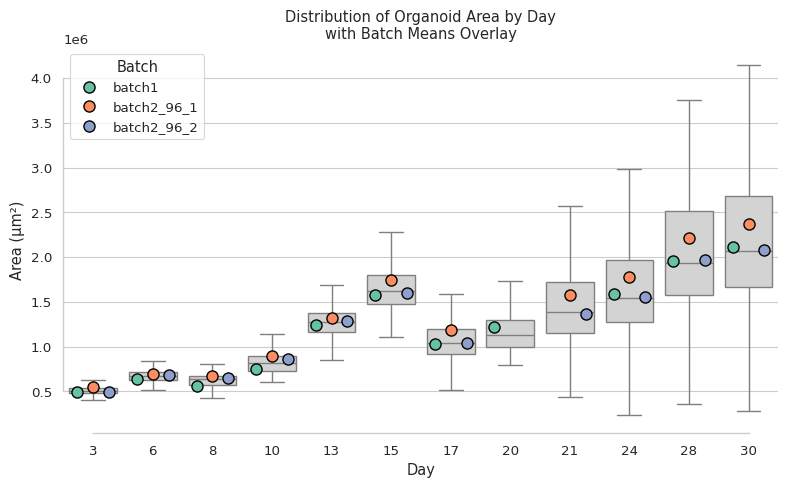

In [12]:
df = df[df["batch_day"].isin(["batch1", "batch2_96_1", "batch2_96_2"])].copy()
df["day"]   = df["img_id"].str.extract(r"Dy(\d+)", expand=False).astype(int)
df["batch"] = df["batch_day"]
metric = "area_um2"

# 2) Compute batch‐day means
means = df.groupby(["batch","day"])[metric].mean().reset_index()

# 3) Plot
sns.set_theme(context="paper", style="whitegrid", palette="Set2", font="sans-serif", font_scale=1.1)
plt.figure(figsize=(8,5))

# A) The grey boxplot of *all* measurements by day
ax = sns.boxplot(
    data=df,
    x="day", y=metric,
    color="lightgray",
    showfliers=False
)

# B) Overlay batch means with dodge=True so they align under each day
sns.stripplot(
    data=means,
    x="day", y=metric,
    hue="batch",
    palette="Set2",
    dodge=True,        # align under each day
    size=8,
    marker="o",
    edgecolor="k",
    linewidth=1,
    ax=ax
)

# 4) Final touches
ax.set_xlabel("Day")
ax.set_ylabel("Area (µm²)")
ax.set_title("Distribution of Organoid Area by Day\nwith Batch Means Overlay")
sns.despine(trim=True)
plt.legend(title="Batch", loc="upper left")
plt.tight_layout()
plt.show()